In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [16]:
data = pd.read_excel("Adidas US Sales Datasets.xlsx")

In [17]:
data.head()

,Retailer,Retailer ID,Invoice Date,Region,State,City,Product,Price per Unit,Units Sold,Total Sales,Operating Profit,Operating Margin,Sales Method
0,Foot Locker,1185732,2020-01-01,Northeast,New York,New York,Men's Street Footwear,50.0,1200,600000.0,300000.0,0.50,In-store
1,Foot Locker,1185732,2020-01-02,Northeast,New York,New York,Men's Athletic Footwear,50.0,1000,500000.0,150000.0,0.30,In-store
2,Foot Locker,1185732,2020-01-03,Northeast,New York,New York,Women's Street Footwear,40.0,1000,400000.0,140000.0,0.35,In-store
3,Foot Locker,1185732,2020-01-04,Northeast,New York,New York,Women's Athletic Footwear,45.0,850,382500.0,133875.0,0.35,In-store
4,Foot Locker,1185732,2020-01-05,Northeast,New York,New York,Men's Apparel,60.0,900,540000.0,162000.0,0.30,In-store


In [18]:
data.shape

(9648, 13)

In [19]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9648 entries, 0 to 9647
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Retailer          9648 non-null   object        
 1   Retailer ID       9648 non-null   int64         
 2   Invoice Date      9648 non-null   datetime64[ns]
 3   Region            9648 non-null   object        
 4   State             9648 non-null   object        
 5   City              9648 non-null   object        
 6   Product           9648 non-null   object        
 7   Price per Unit    9648 non-null   float64       
 8   Units Sold        9648 non-null   int64         
 9   Total Sales       9648 non-null   float64       
 10  Operating Profit  9648 non-null   float64       
 11  Operating Margin  9648 non-null   float64       
 12  Sales Method      9648 non-null   object        
dtypes: datetime64[ns](1), float64(4), int64(2), object(6)
memory usage: 980.0+ KB


In [20]:
data.isnull().sum()

Retailer            0
Retailer ID         0
Invoice Date        0
Region              0
State               0
City                0
Product             0
Price per Unit      0
Units Sold          0
Total Sales         0
Operating Profit    0
Operating Margin    0
Sales Method        0
dtype: int64

In [21]:
data.describe()

,Retailer ID,Invoice Date,Price per Unit,Units Sold,Total Sales,Operating Profit,Operating Margin
count,9.648000e+03,9648,9648.000000,9648.000000,9648.000000,9648.000000,9648.000000
mean,1.173850e+06,2021-05-10 15:20:44.776119296,45.216625,256.930037,93273.437500,34425.244761,0.422991
min,1.128299e+06,2020-01-01 00:00:00,7.000000,0.000000,0.000000,0.000000,0.100000
25%,1.185732e+06,2021-02-17 00:00:00,35.000000,106.000000,4254.500000,1921.752500,0.350000
50%,1.185732e+06,2021-06-04 00:00:00,45.000000,176.000000,9576.000000,4371.420000,0.410000
75%,1.185732e+06,2021-09-16 00:00:00,55.000000,350.000000,150000.000000,52062.500000,0.490000
max,1.197831e+06,2021-12-31 00:00:00,110.000000,1275.000000,825000.000000,390000.000000,0.800000
std,2.636038e+04,NaN,14.705397,214.252030,141916.016727,54193.113713,0.097197


In [22]:
data.duplicated().sum()

0

### Extracting date properties

In [23]:
# Extracting the year

data["Year"] = data["Invoice Date"].dt.year

In [24]:
# Extracting the month

data["Month"] = data["Invoice Date"].dt.month

In [25]:
# Extracting the quarter

data["Quarter"] = data["Invoice Date"].dt.quarter

In [26]:
# Extracting the month name

data["Month Name"] = data["Invoice Date"].dt.month_name()

In [27]:
# Extracting the day number

data["Day Number"] = data["Invoice Date"].dt.dayofweek + 1

In [28]:
# Extracting the day name

data["Day Name"] = data["Invoice Date"].dt.day_name()

### Standardizing text-based columns

In [29]:
data["Retailer"] = data["Retailer"].str.strip().str.title()

In [30]:
data["Region"] = data["Region"].str.strip().str.title()

In [31]:
data["State"] = data["State"].str.strip().str.title()

In [32]:
data["City"] = data["City"].str.strip().str.title()

In [33]:
data["Product"] = data["Product"].str.strip().str.title().str.replace("'S", "'s", regex = False)

In [34]:
data["Sales Method"] = data["Sales Method"].str.strip().str.title()

In [35]:
data["Gender"] = data["Product"].str.extract(r"^(Men's|Women's)")

In [36]:
data["Category"] = data["Product"].str.extract(r"(Apparel|Footwear|Athletic Footwear|Street Footwear)")

### Creating a Revenue per Unit column to verify Total Sales

In [37]:
data["Revenue Per Unit"] = data["Total Sales"]/data["Units Sold"]

In [39]:
data.to_excel("cleaned_adidas.xlsx", index = False)

### Basic visualisations

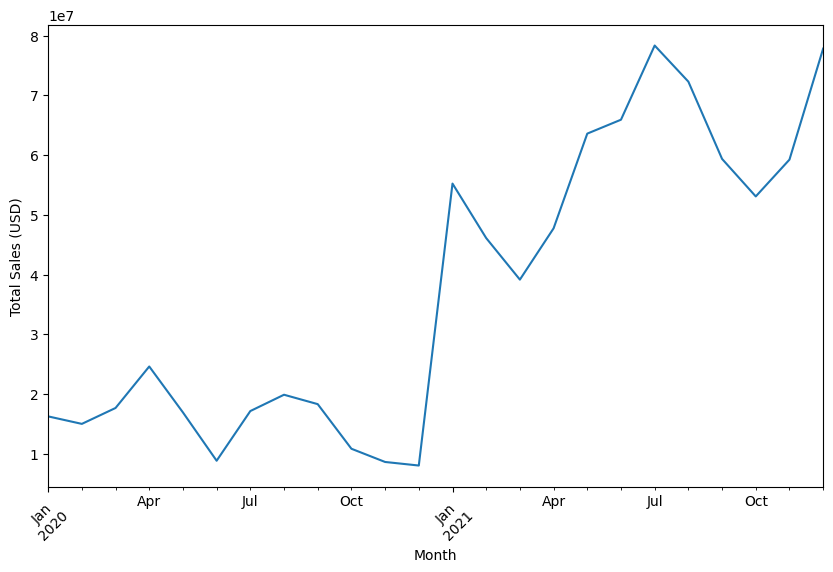

In [ ]:
# Monthly sales

monthly_sales = data.groupby(data["Invoice Date"].dt.to_period("M"))["Total Sales"].sum()
monthly_sales.index = monthly_sales.index.to_timestamp()

ax = monthly_sales.plot(figsize = (10, 6))
ax.set_xlabel("Month")
ax.set_ylabel("Total Sales (USD)")
plt.xticks(rotation = 45)
plt.show()

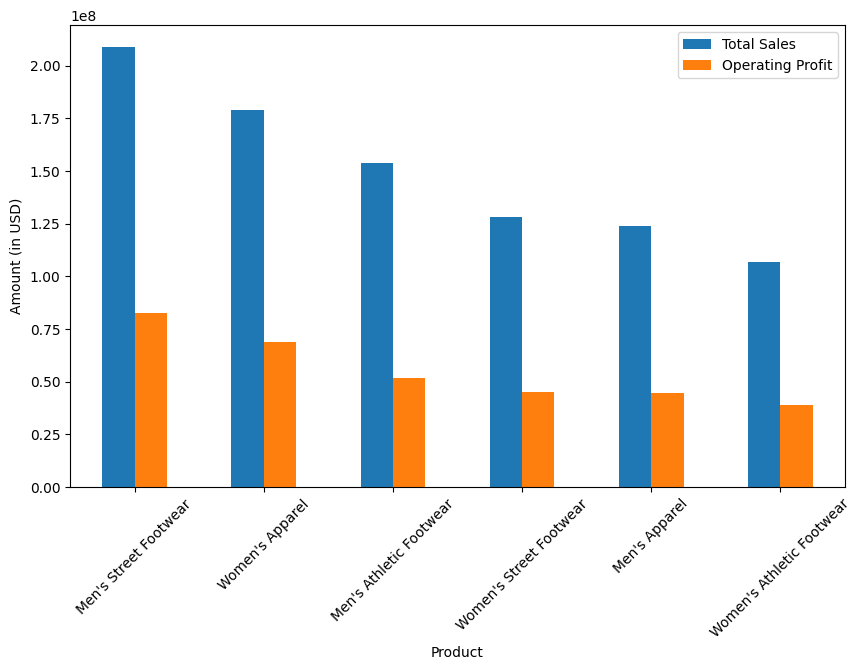

In [ ]:
# Revenue vs Profit

product_performance = data.groupby("Product")[["Total Sales", "Operating Profit"]].sum().sort_values("Total Sales", ascending = False)
product_performance.plot(kind =  "bar", figsize = (10, 6))
plt.xlabel("Product")
plt.ylabel("Amount (in USD)")
plt.xticks(rotation = 45)
plt.show()

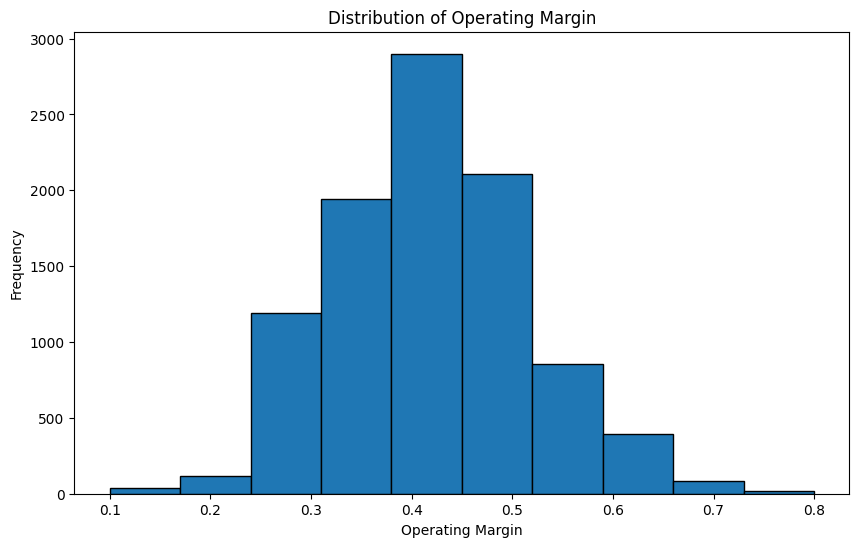

In [ ]:
# Distribution of operating margins

data["Operating Margin"].plot(kind = "hist", bins = 10, figsize = (10, 6), edgecolor = "black")
plt.title("Distribution of Operating Margin")
plt.xlabel("Operating Margin")
plt.ylabel("Frequency")
plt.show()

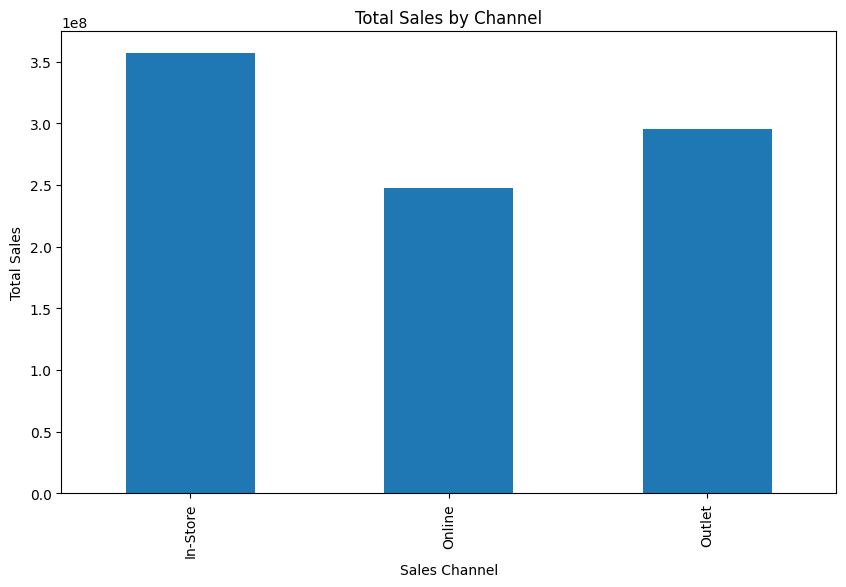

In [ ]:
# Total sales by different sales methods

channel_sales = data.groupby("Sales Method")["Total Sales"].sum()
channel_sales.plot(kind = "bar", figsize = (10, 6))
plt.title("Total Sales by Channel")
plt.xlabel("Sales Channel")
plt.ylabel("Total Sales")
plt.show()